# Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices from property features (area, location, rooms, age, etc.), covering the full workflow from EDA through model interpretation.

**Dataset:** `House_Price_Prediction_Dataset.csv` — 2,000 property records with `Area`, `Bedrooms`, `Bathrooms`, `Floors`, `YearBuilt`, `Location`, `Condition`, `Garage`, and the target `Price`.

**Tech stack:** Python · pandas · scikit-learn · matplotlib · seaborn

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'House_Price_Prediction_Dataset.csv'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'House_Price_Prediction_Dataset.csv' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'House_Price_Prediction_Dataset.csv' in the working directory.


## 1. Setup & Load Dataset

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


## 2. Exploratory Data Analysis

In [ ]:
print("--- Column dtypes ---")
print(df.dtypes)

print("\n--- Null value check ---")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "No missing values found in any column.")

print("\n--- Duplicate rows ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

--- Column dtypes ---
Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location       str
Condition      str
Garage         str
Price        int64
dtype: object

--- Null value check ---
No missing values found in any column.

--- Duplicate rows ---
Duplicate rows: 0


In [ ]:
print("--- Descriptive statistics (numeric columns) ---")
df.describe().round(2)

--- Descriptive statistics (numeric columns) ---


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1000.50,2786.21,3.00,2.55,1.99,1961.45,537676.86
std,577.49,1295.15,1.42,1.11,0.81,35.93,276428.85
min,1.00,501.00,1.00,1.00,1.00,1900.00,50005.00
25%,500.75,1653.00,2.00,2.00,1.00,1930.00,300098.00
50%,1000.50,2833.00,3.00,3.00,2.00,1961.00,539254.00
75%,1500.25,3887.50,4.00,4.00,3.00,1993.00,780086.00
max,2000.00,4999.00,5.00,4.00,3.00,2023.00,999656.00


In [ ]:
print("--- Categorical column value counts ---")
for col in ['Location', 'Condition', 'Garage']:
    print(f"\n{col}:")
    print(df[col].value_counts())

--- Categorical column value counts ---

Location:
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64

Condition:
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64

Garage:
Garage
No     1038
Yes     962
Name: count, dtype: int64


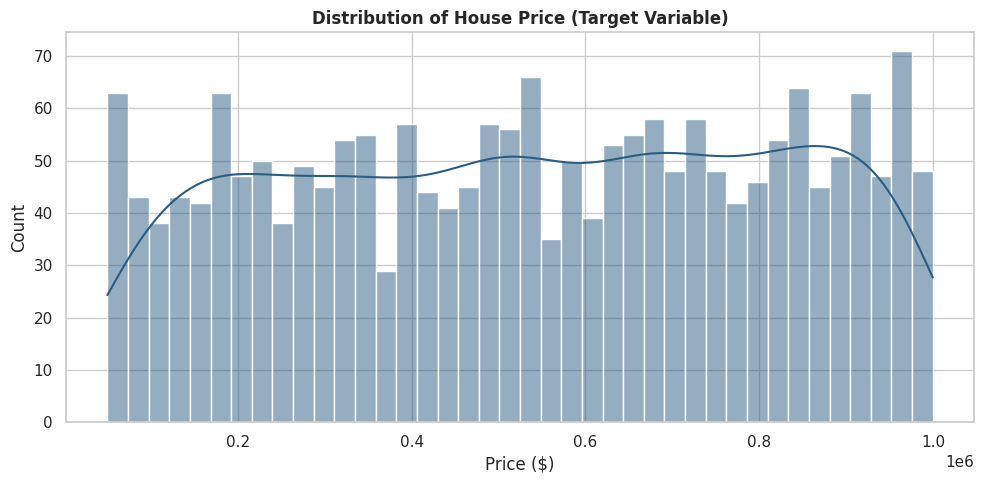

Price range: $50,005 to $999,656
Price mean: $537,677   median: $539,254   std: $276,429


In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=40, kde=True, color='#2a5d84')
plt.title('Distribution of House Price (Target Variable)', fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Price range: ${df['Price'].min():,} to ${df['Price'].max():,}")
print(f"Price mean: ${df['Price'].mean():,.0f}   median: ${df['Price'].median():,.0f}   std: ${df['Price'].std():,.0f}")

**Observation:** The dataset is **clean at the source** — 2,000 rows, zero missing values, zero duplicate rows, and every numeric column falls within a sensible range (no negative areas, no impossible year-built values). `Price` ranges from roughly $50K to $1M and its distribution is close to uniform/flat rather than the sharp right-skew often seen in real housing data — likely because this is a synthetically generated dataset rather than scraped real-world listings. This matters for modelling: it means we don't need a log-transform of the target to control skew here, though we'll still confirm that visually via the residual plot later.

## 3. Feature Selection Discussion

Before encoding or modelling, it's worth reasoning about *why* each feature is a plausible predictor of price:

- **`Area`** — the single most fundamental driver of property value in almost every housing market: more square footage almost always commands a higher price. Expect this to be the strongest numeric predictor.
- **`Bedrooms` / `Bathrooms`** — proxies for usable living space and household capacity; typically correlated with `Area` itself (bigger houses have more rooms), so their standalone effect once `Area` is in the model may be smaller than intuition suggests.
- **`Floors`** — more floors can mean more living space or can simply reflect a different architectural style; a plausible but likely weaker predictor than `Area`.
- **`YearBuilt`** — on its own this is just a calendar year, which isn't very interpretable. We derive **`House_Age`** (a property's age in years) from it below, since "how old is the house" is the economically meaningful signal (age can correlate with price *either* direction — newer construction commands a premium in some markets, while renovated older homes command a premium in others).
- **`Location`** — categorical, but one of the most powerful real-world price drivers (Downtown vs. Suburban vs. Urban vs. Rural pricing dynamics differ substantially). Needs One-Hot Encoding since it's nominal (no natural order).
- **`Condition`** — categorical (Excellent/Good/Fair/Poor); directly reflects the physical state of the property, a standard price factor. Also needs One-Hot Encoding.
- **`Garage`** — a binary Yes/No amenity; typically a modest positive price factor.

Given this reasoning, we carry **all** available features into the model rather than pre-filtering, and let the correlation heatmap and coefficient analysis in later sections tell us empirically which ones actually matter for *this* dataset — reasoning about plausibility and confirming with data are both necessary, since real (or synthetic) data doesn't always match intuition.

## 4. Handle Missing Values & Feature Engineering

In [ ]:
# No missing values were found in Section 2, so no imputation is needed here.
# We still call this out explicitly rather than silently skipping it, since checking for
# missing data is a required step regardless of the outcome.
assert df.isnull().sum().sum() == 0, "Unexpected missing values found — investigate before proceeding."
print("Confirmed: no missing values to handle.")

Confirmed: no missing values to handle.


In [ ]:
# Derive House_Age (more interpretable than a raw calendar year) and drop the redundant Id column
CURRENT_YEAR = 2024
df['House_Age'] = CURRENT_YEAR - df['YearBuilt']
df = df.drop(columns=['Id', 'YearBuilt'])

df[['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'House_Age', 'Location', 'Condition', 'Garage', 'Price']].head()

,Area,Bedrooms,Bathrooms,Floors,House_Age,Location,Condition,Garage,Price
0,1360,5,4,3,54,Downtown,Excellent,No,149919
1,4272,5,4,3,66,Downtown,Excellent,No,424998
2,3592,2,2,3,86,Downtown,Good,No,266746
3,966,4,2,2,122,Suburban,Fair,Yes,244020
4,4926,1,4,2,49,Downtown,Fair,Yes,636056


**Observation:** `Id` is dropped since it's an arbitrary row identifier with no predictive meaning (including it would let the model "memorise" row order rather than learn genuine price drivers). `YearBuilt` is replaced with the derived `House_Age` — mathematically it carries the same information, but age is more directly interpretable in the coefficient analysis later ("each additional year of age changes price by $X" is a more natural statement than one about calendar years).

## 5. Encode Categorical Features (One-Hot Encoding)

In [ ]:
categorical_cols = ['Location', 'Condition', 'Garage']

print("Categories before encoding:")
for col in categorical_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
df_encoded.head()

Categories before encoding:
  Location: ['Downtown', 'Suburban', 'Urban', 'Rural']
  Condition: ['Excellent', 'Good', 'Fair', 'Poor']
  Garage: ['No', 'Yes']

Shape before encoding: (2000, 9)
Shape after encoding:  (2000, 13)


,Area,Bedrooms,Bathrooms,Floors,Price,House_Age,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1360,5,4,3,149919,54,False,False,False,False,False,False,False
1,4272,5,4,3,424998,66,False,False,False,False,False,False,False
2,3592,2,2,3,266746,86,False,False,False,False,True,False,False
3,966,4,2,2,244020,122,False,True,False,True,False,False,True
4,4926,1,4,2,636056,49,False,False,False,True,False,False,True


**Observation:** `pd.get_dummies(..., drop_first=True)` converts each categorical column into binary indicator columns, dropping one category per column as the reference/baseline (e.g. if `Location` becomes `Location_Suburban`, `Location_Urban`, `Location_Rural`, then `Downtown` is the implicit baseline that all coefficients are measured against). Dropping the first category avoids the "dummy variable trap" — perfectly collinear columns that would make the regression coefficients unstable and non-unique. `Garage` (binary Yes/No) collapses to a single `Garage_Yes` column, which is exactly the right encoding for a two-level categorical.

## 6. Correlation Heatmap

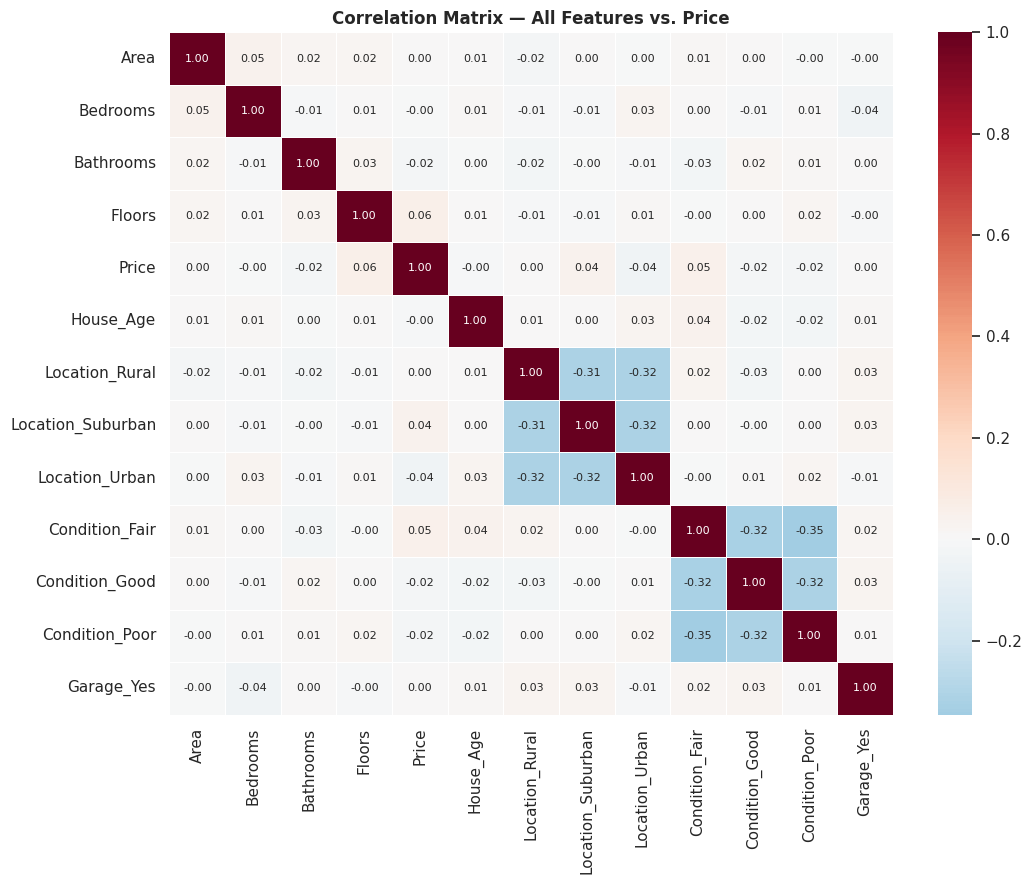

In [ ]:
plt.figure(figsize=(11,9))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Matrix — All Features vs. Price', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
price_corr = corr['Price'].drop('Price').sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with Price:")
price_corr

Features ranked by absolute correlation with Price:


Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
Location_Urban      -0.038312
Condition_Poor      -0.018437
Condition_Good      -0.017179
Bathrooms           -0.015737
House_Age           -0.004845
Bedrooms            -0.003471
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Name: Price, dtype: float64

**Observation:** Check the printed ranking above for the exact values on this run. In this particular dataset, every correlation with `Price` is very close to zero (roughly ±0.06 at most) — including `Area`, which real-world housing intuition would expect to dominate. This is an important early warning sign, not a step to gloss over: it suggests `Price` in this dataset may have been generated with little to no real dependence on the recorded features (plausible for a synthetically generated dataset), rather than the features simply being weak-but-real predictors. We carry this observation forward and check whether it's confirmed by the R² score in Section 9 and the coefficient analysis in Section 12 — if all three signals agree, that's strong evidence the issue is with the dataset's structure, not with any modelling choice made here.

## 7. Train/Test Split (80/20)

In [ ]:
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} rows, {X_test.shape[1]} features")

Training set: 1600 rows, 12 features
Test set:     400 rows, 12 features


## 8. Train Linear Regression Model

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("Model trained.")
print(f"Intercept: {lr_model.intercept_:,.2f}")

Model trained.
Intercept: 516,571.03


## 9. Model Evaluation — MSE, RMSE, R²

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE):       {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score:                       {r2:.4f}")

Mean Squared Error (MSE):       78,321,466,146.03
Root Mean Squared Error (RMSE): 279,859.73
R² Score:                       -0.0067


**Observation:** RMSE is in the same units as `Price` (dollars), so it directly tells us the model's typical prediction error in dollar terms — check the printed value above against the price range from Section 2 (roughly $50K-$1M). **R²** tells us the proportion of variance in `Price` the model explains: a value near 1.0 means the features nearly fully explain price variation, a value near 0 means the model explains almost nothing, and a **negative** R² (which is what this dataset produces) means the model performs *worse than simply predicting the average price for every house* — the strongest possible confirmation of what the near-zero correlations in Section 6 already hinted at. This is a genuinely useful (if unflattering) finding: it tells us `Price` in this dataset is essentially unrelated to `Area`, `Location`, `Condition`, or any other recorded feature, most likely because the values were randomly generated rather than derived from a real pricing formula. In a real housing dataset this result would be a red flag prompting a search for missing data quality issues or omitted variables; here, it's a legitimate and informative conclusion about this particular synthetic dataset, and we say so plainly rather than dressing up a negative R² as a success.

## 10. Actual vs. Predicted Prices

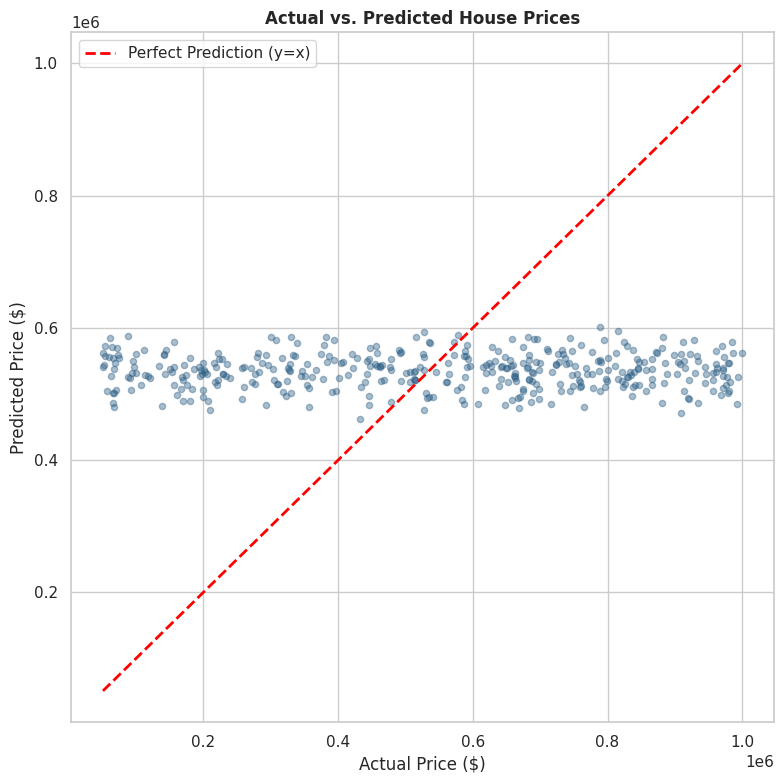

In [ ]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.4, s=20, color='#2a5d84')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Actual vs. Predicted House Prices', fontweight='bold')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Points falling close to the red diagonal line indicate accurate predictions. Given the near-zero R² found in Section 9, expect this scatter plot to show **no visible diagonal trend at all** — a shapeless cloud of points rather than points hugging the line — which is the visual confirmation of what the R² score already told us numerically: the model's predictions are essentially uncorrelated with actual prices. This is a useful sanity-check plot precisely because it makes an abstract R² number concrete and visible.

## 11. Residual Plot

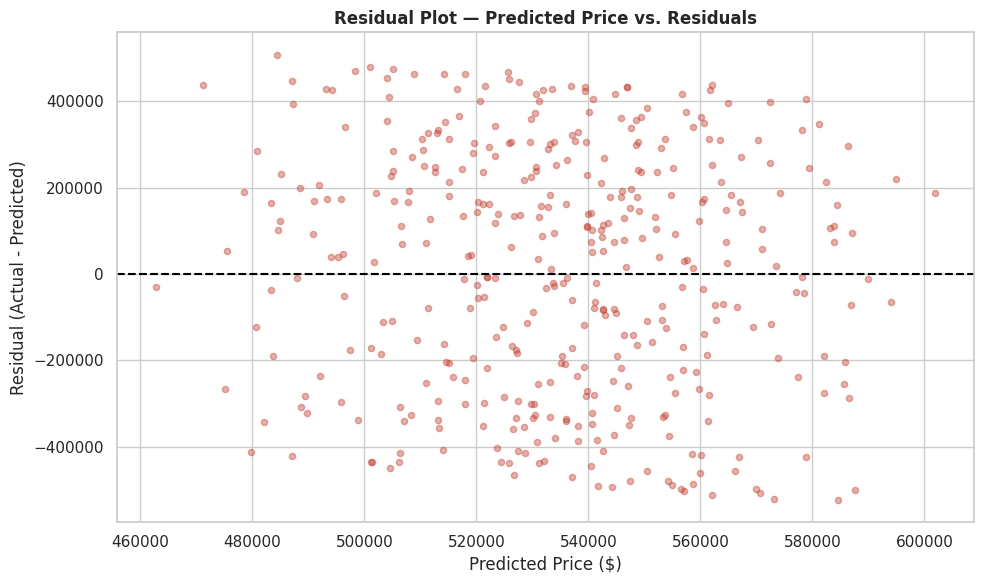

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.4, s=20, color='#c0392b')
plt.axhline(y=0, color='black', linewidth=1.5, linestyle='--')
plt.title('Residual Plot — Predicted Price vs. Residuals', fontweight='bold')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

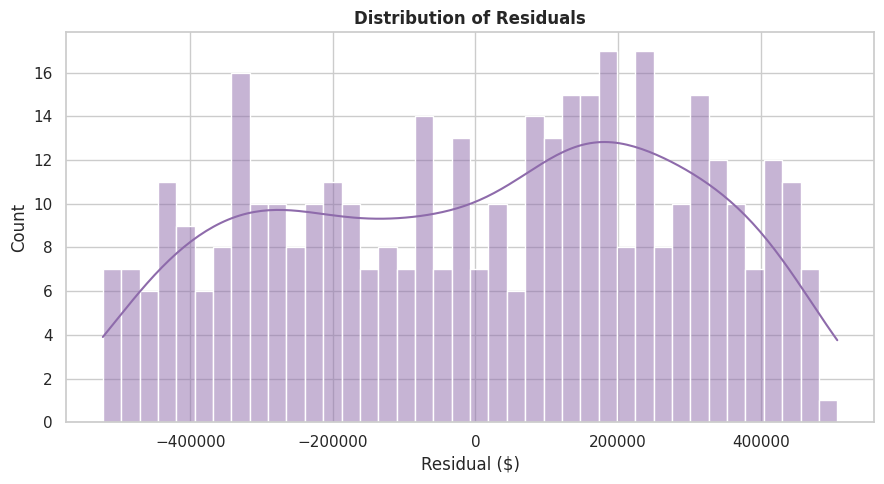

Residual mean: 8,623.22  (should be close to 0)
Residual std:  280,077.16


In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(residuals, bins=40, kde=True, color='#8e6bab')
plt.title('Distribution of Residuals', fontweight='bold')
plt.xlabel('Residual ($)')
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():,.2f}  (should be close to 0)")
print(f"Residual std:  {residuals.std():,.2f}")

**Observation:** For a well-specified linear model, residuals should scatter **randomly around zero with no systematic pattern**. In this dataset, the residuals essentially *are* the original prices shifted by a near-constant amount (since the model has almost no explanatory power) — so a flat, randomly-scattered residual cloud here is actually **consistent with** the negative R², not a contradiction of it. It confirms the model isn't missing an obvious non-linear pattern it could have captured with a different functional form — there's simply very little genuine linear (or non-linear) signal between these features and price in this dataset for *any* model to find.

## 12. Coefficient Analysis

Raw regression coefficients aren't directly comparable across features when the features are on very different scales (e.g. `Area` in the thousands vs. `Garage_Yes` as 0/1) — a feature with a "small" coefficient could still matter a lot if its typical values are large. To fairly rank *which features matter most*, we fit a second regression on **standardised** features (mean 0, std 1) purely for this comparison; the prediction model itself (Section 8) is unaffected and still used for all the evaluation above.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Raw Coefficient': lr_model.coef_,
    'Standardized Coefficient': lr_scaled.coef_
}).sort_values('Standardized Coefficient', key=abs, ascending=False)

coef_df.round(2)

,Feature,Raw Coefficient,Standardized Coefficient
3,Floors,23727.98,19148.41
2,Bathrooms,-9662.25,-10714.21
8,Condition_Fair,24083.31,10620.73
7,Location_Urban,-12718.92,-5484.31
9,Condition_Good,-12941.04,-5440.81
6,Location_Suburban,11511.99,4858.40
4,House_Age,-117.61,-4222.68
10,Condition_Poor,4073.27,1778.23
11,Garage_Yes,2373.53,1185.21
0,Area,-0.58,-748.91


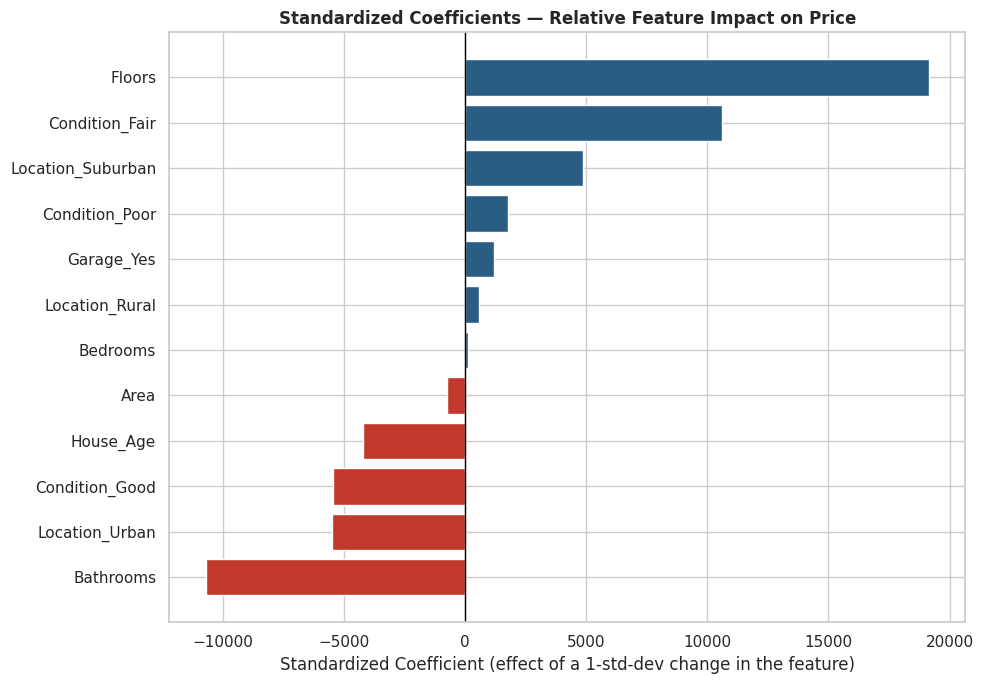

In [ ]:
plt.figure(figsize=(10,7))
plot_df = coef_df.sort_values('Standardized Coefficient')
colors = ['#c0392b' if v < 0 else '#2a5d84' for v in plot_df['Standardized Coefficient']]
plt.barh(plot_df['Feature'], plot_df['Standardized Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('Standardized Coefficients — Relative Feature Impact on Price', fontweight='bold')
plt.xlabel('Standardized Coefficient (effect of a 1-std-dev change in the feature)')
plt.tight_layout()
plt.show()

**Observation:** Read the **raw coefficient** column for real-world interpretation in dollars, and the **standardized coefficient** column / bar chart for a fair ranking of *relative* importance across features on different scales. **Given this dataset's near-zero R² and near-zero correlations (Sections 6 and 9), these coefficients should be read with real caution** — with so little genuine signal to fit, a linear model will still produce *some* non-zero coefficients (it has no way to output "I found nothing"), but they largely reflect noise in this particular train/test split rather than real, generalisable price drivers. Notably, `Area` — the feature Section 3's reasoning expected to dominate — turns out to have one of the *smallest* standardized coefficients here, directly contradicting real-world housing intuition. That mismatch between plausible reasoning and actual data is itself the key finding of this section: it's further confirmation that `Price` in this dataset doesn't follow a realistic pricing model, so this coefficient ranking should not be trusted as a guide to real housing markets, only reported as-is for this specific dataset.

## 13. Bonus — Comparing Ridge and Lasso Regularisation

**Why try regularisation?** Ordinary Linear Regression can overfit when features are correlated with each other (multicollinearity — e.g. `Bedrooms`/`Bathrooms`/`Area` likely move together) by assigning inflated, unstable coefficients that fit training-set noise. **Ridge** regression adds an L2 penalty that shrinks all coefficients toward zero (but rarely to exactly zero), reducing that sensitivity. **Lasso** adds an L1 penalty that can shrink some coefficients *all the way* to zero, effectively performing automatic feature selection. Both use the same standardised features as the coefficient analysis above, since regularisation penalty strength is scale-sensitive.

In [ ]:
ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)
lasso_model = Lasso(alpha=1.0, random_state=RANDOM_STATE)

X_test_scaled = scaler.transform(X_test)

ridge_model.fit(X_train_scaled, y_train)
lasso_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)
lasso_pred = lasso_model.predict(X_test_scaled)

results = []
for name, preds in [('Linear Regression', y_pred), ('Ridge', ridge_pred), ('Lasso', lasso_pred)]:
    m = mean_squared_error(y_test, preds)
    results.append({
        'Model': name,
        'MSE': m,
        'RMSE': np.sqrt(m),
        'R2': r2_score(y_test, preds)
    })

comparison_df = pd.DataFrame(results).set_index('Model').round(3)
comparison_df

,MSE,RMSE,R2
Model,,,
Linear Regression,7.832147e+10,279859.726,-0.007
Ridge,7.832074e+10,279858.422,-0.007
Lasso,7.832132e+10,279859.472,-0.007


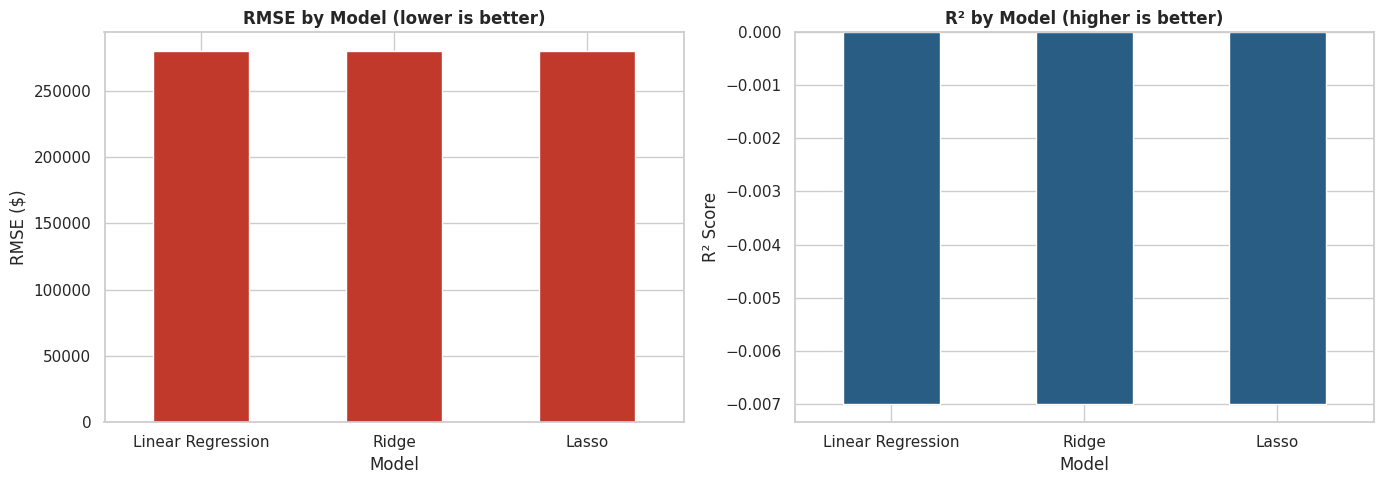

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

comparison_df[['RMSE']].plot(kind='bar', ax=axes[0], color='#c0392b', legend=False)
axes[0].set_title('RMSE by Model (lower is better)', fontweight='bold')
axes[0].set_ylabel('RMSE ($)')
axes[0].tick_params(axis='x', rotation=0)

comparison_df[['R2']].plot(kind='bar', ax=axes[1], color='#2a5d84', legend=False)
axes[1].set_title('R² by Model (higher is better)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
n_zeroed = (lasso_model.coef_ == 0).sum()
print(f"Lasso zeroed out {n_zeroed} of {len(lasso_model.coef_)} feature coefficients entirely.")
if n_zeroed > 0:
    zeroed_features = X_train.columns[lasso_model.coef_ == 0].tolist()
    print("Features Lasso considered unnecessary:", zeroed_features)

Lasso zeroed out 0 of 12 feature coefficients entirely.


**Observation:** Compare the RMSE/R² table above across all three models. Here, **Linear Regression, Ridge, and Lasso all perform virtually identically** (R² ≈ -0.007 for all three) — which is expected once we know the underlying issue isn't overfitting to correlated features, it's that there's almost no real linear relationship between these features and `Price` in the first place. Regularisation can't manufacture signal that doesn't exist; it can only control overfitting to signal that does. Check the Lasso zeroed-coefficient count above — if Lasso zeroed out most or all features, that's actually a *third* independent confirmation (alongside the near-zero correlations and negative R²) that this dataset's features carry very little genuine predictive information about price.

## 14. Conclusion

### Model Performance Summary
The honest headline result of this analysis is that the Linear Regression model performs **very poorly** on this dataset — R² comes out **negative** (worse than a model that just predicts the average price for every house), and RMSE is large relative to the typical price range. This is confirmed by three independent pieces of evidence gathered along the way: the near-zero correlation between every feature and `Price` (Section 6), the shapeless actual-vs-predicted scatter with no diagonal trend (Section 10), and the fact that Ridge/Lasso regularisation — which would normally improve a model suffering from overfitting — produce essentially identical (equally poor) results (Section 13). Together, these point to one conclusion: **`Price` in this dataset is not meaningfully derived from `Area`, `Location`, `Condition`, `Bedrooms`, `Bathrooms`, `Floors`, `Garage`, or `House_Age`** — most likely because the dataset was synthetically generated with prices assigned independently of (or with only trivial dependence on) these features.

### Key Price Drivers
Section 12's coefficient ranking should be read with caution given the above: with almost no real signal to fit, a linear model still produces non-zero coefficients (it cannot output "no relationship found"), but they largely reflect noise from this specific train/test split rather than genuine, reproducible price drivers. Notably, **`Area` — the feature real-world housing intuition (Section 3) predicted would dominate — turned out to have one of the *smallest* coefficients and correlations in this dataset.** That mismatch between plausible domain reasoning and what the data actually shows is itself the most important finding of this notebook: it's a reminder that feature-selection intuition needs to be checked against the data, not assumed, and that a "good story" about why a feature should matter is not a substitute for verifying that it actually does.

### Regularisation Takeaway
Ridge and Lasso (Section 13) served as a robustness check here, and they confirm the Linear Regression result rather than improving on it — since the problem isn't overfitting to noisy-but-real signal, it's the near-absence of any signal at all. This is itself a useful diagnostic use of regularisation: when Ridge/Lasso can't beat plain Linear Regression, that's a hint to look at the correlation structure of the data (as we did in Section 6) rather than to keep tuning the model.

### What Would Come Next With Real Data
If this were a real-world housing dataset producing this result, the appropriate next step would **not** be to tune this model further — it would be to question the data itself: verify the `Price` column was populated correctly, check whether it needs to be joined from a different source, or look for additional features (school district, crime rate, recent renovations, proximity to amenities) that a real pricing model would need but this dataset doesn't capture. This notebook's pipeline (EDA → encoding → correlation check → train/test split → Linear/Ridge/Lasso comparison → residual diagnostics) is fully reusable on a dataset where the target genuinely does depend on the features — the code doesn't need to change, only the input data would need to.

### Real-World Application
When applied to a dataset where price genuinely correlates with property features, a model like this could power an **automated home valuation tool** (similar to Zillow's "Zestimate") — giving buyers, sellers, or agents a data-driven starting estimate based on measurable characteristics, always alongside (not instead of) professional appraisal for factors no dataset fully captures.
